# Laboratorio 7 — NLP end-to-end y Embeddings
**CC3092 · Deep Learning y Sistemas Inteligentes** — Esteban Cárcamo (23016)

Pipeline: texto crudo → tokens → IDs → vectores → modelo → salida. Los entrenamientos largos corren en `scripts/`
(guardan JSON en `results/`); aquí se usa el mismo código de `src/lab7` con demos cortas y se leen esos resultados.

In [1]:
import inspect
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Image, Markdown, display

LAB = Path.cwd().parent
sys.path.insert(0, str(LAB / "src"))
from lab7 import classify, data, evaluation, sgns

R = LAB / "results"
FIG = R / "figures"
load = lambda name: json.loads((R / name).read_text())
pd.set_option("display.max_colwidth", 120)
pct = lambda x: f"{100 * x:.1f} %"

## 1. Datos
WikiText-103 (corpus para los embeddings), AG News (clasificación) y GloVe 100d (referencia).

In [2]:
from datasets import load_dataset

wiki_val = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="validation")
news = load_dataset("fancyzhx/ag_news")
print([line for line in wiki_val["text"][:6]])
print(news["train"][0])

['', ' = Homarus gammarus = \n', '', ' Homarus gammarus , known as the European lobster or common lobster , is a species of clawed lobster from the eastern Atlantic Ocean , Mediterranean Sea and parts of the Black Sea . It is closely related to the American lobster , H. americanus . It may grow to a length of 60 cm ( 24 in ) and a mass of 6 kilograms ( 13 lb ) , and bears a conspicuous pair of claws . In life , the lobsters are blue , only becoming " lobster red " on cooking . Mating occurs in the summer , producing eggs which are carried by the females for up to a year before hatching into planktonic larvae . Homarus gammarus is a highly esteemed food , and is widely caught using lobster pots , mostly around the British Isles . \n', '', ' = = Description = = \n']
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


## 2. Exploración y preprocesamiento
### 2.1 Tamaño del corpus

In [3]:
stats = load("corpus_stats.json")
display(pd.DataFrame(stats["splits"]).T)
print(f"Train normalizado: {stats['train_normalized_tokens']:,} tokens")
print(f"Subconjunto de entrenamiento: {stats['subset']['articles']:,} artículos, {stats['subset']['lines']:,} líneas, {stats['subset']['tokens']:,} tokens")

,articles,lines,non_empty_lines,raw_tokens
test,62,4358,2891,241211
train,29444,1801350,1165029,101425671
validation,60,3760,2461,213886


Train normalizado: 85,870,879 tokens
Subconjunto de entrenamiento: 8,802 artículos, 251,800 líneas, 25,000,786 tokens


### 2.2 Normalización
Minúsculas; `@-@` separa, `@,@`/`@.@` unen números; se descartan títulos y puntuación; contracciones estilo Treebank
(`n't`, `'s`) como en GloVe. Así el vocabulario coincide con el de GloVe y la comparación es justa.

In [4]:
raw = wiki_val["text"][3][:260]
print("crudo:      ", raw)
print("normalizado:", data.normalize(raw))
print("tokens:     ", data.tokenize(raw))

crudo:        Homarus gammarus , known as the European lobster or common lobster , is a species of clawed lobster from the eastern Atlantic Ocean , Mediterranean Sea and parts of the Black Sea . It is closely related to the American lobster , H. americanus . It may grow to
normalizado:  homarus gammarus , known as the european lobster or common lobster , is a species of clawed lobster from the eastern atlantic ocean , mediterranean sea and parts of the black sea . it is closely related to the american lobster , h. americanus . it may grow to
tokens:      ['homarus', 'gammarus', 'known', 'as', 'the', 'european', 'lobster', 'or', 'common', 'lobster', 'is', 'a', 'species', 'of', 'clawed', 'lobster', 'from', 'the', 'eastern', 'atlantic', 'ocean', 'mediterranean', 'sea', 'and', 'parts', 'of', 'the', 'black', 'sea', 'it', 'is', 'closely', 'related', 'to', 'the', 'american', 'lobster', 'h', 'americanus', 'it', 'may', 'grow', 'to']


### 2.3 Tokenizador propio vs NLTK (Treebank)

In [5]:
cmp_tok = pd.DataFrame(stats["tokenizer_comparison"])[["sentence", "only_ours", "only_nltk", "equal"]]
cmp_tok

,sentence,only_ours,only_nltk,equal
0,Don't you think it's too late?,[],[?],False
1,"The U.S. economy grew 3.5% in 2004, according to Dr. Smith.",[dr],"[%, ,, ., dr.]",False
2,She's a well-known state-of-the-art researcher.,"[art, known, of, state, the, well]","[., state-of-the-art, well-known]",False
3,I can't believe they won't come; we'd better leave.,[],"[., ;]",False
4,"The children's toys cost $1,200.50 at Mr. Brown's shop.",[mr],"[$, ., mr.]",False
5,E-mail me at john@example.com or visit www.example.com.,"[com, e, example, mail, www]","[., @, e-mail, example.com, www.example.com]",False
6,"He said: ""Rock 'n' roll is here to stay!""",[],"[!, ', '', :, ``]",False
7,"The 1990s were a decade of change (e.g., the Internet).","[1990, s]","[(, ), ,, ., 1990s]",False
8,"Mother-in-law's recipes are self-explanatory, aren't they?","[explanatory, in, law, mother, self]","[,, ?, mother-in-law, self-explanatory]",False
9,"New York-based firms hired 20,000 workers in Q3.","[3, based, q, york]","[., q3, york-based]",False


### 2.4 Ley de Zipf

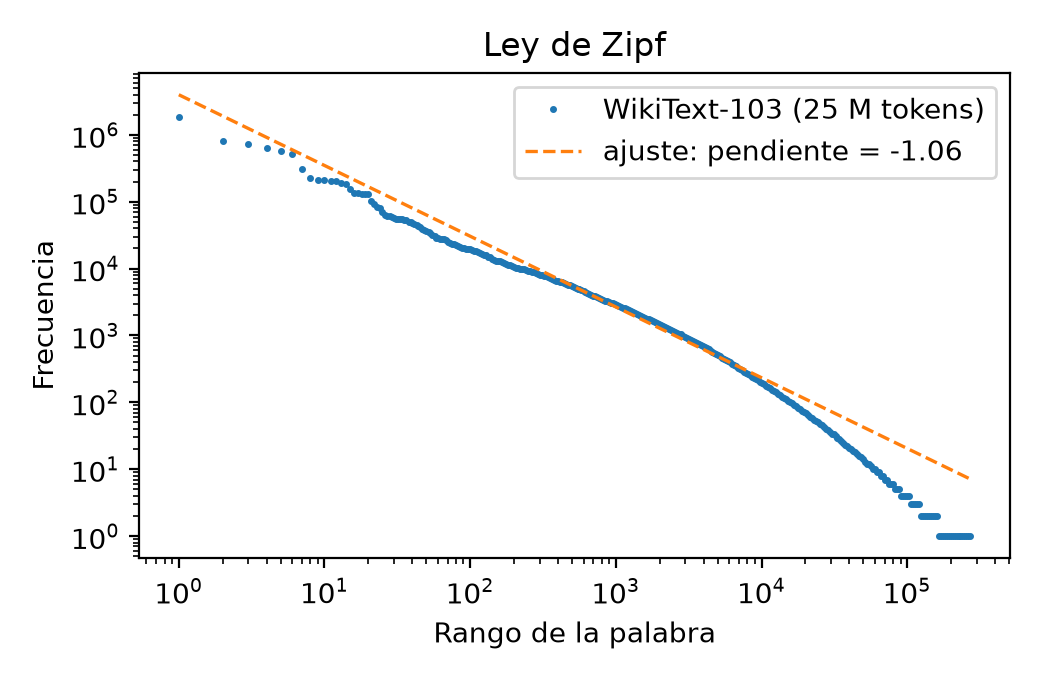

pendiente log-log: -1.058
{'top 10': '24.3 %', 'top 1000': '64.5 %', 'top 30000': '95.8 %'}


In [6]:
display(Image(FIG / "01_zipf.png", width=520))
print("pendiente log-log:", round(stats["zipf"]["slope"], 3))
print({f"top {k}": pct(v) for k, v in stats["coverage"].items()})

### 2.5 Vocabulario según `min_count`

In [7]:
pd.DataFrame(stats["min_count"]).assign(unk_rate=lambda d: d.unk_rate.map(pct))

,min_count,vocab_size,unk_rate
0,1,271737,0.0 %
1,5,90566,1.2 %
2,10,61449,1.9 %
3,20,41805,3.0 %


### 2.6 Subsampling
Fórmula de word2vec/gensim: `keep = (√(f/t) + 1)·t/f`, con t = 1e-4.

In [8]:
pd.DataFrame(stats["subsampling"]["words"]).T.assign(
    frequency=lambda d: d.frequency.map(lambda x: f"{x:.5f}"),
    expected_discard=lambda d: d.expected_discard.map(pct),
    measured_discard=lambda d: d.measured_discard.map(pct),
)

,frequency,expected_discard,measured_discard
the,0.07549,96.2 %,96.2 %
of,0.03231,94.1 %,94.2 %
and,0.02911,93.8 %,93.7 %
in,0.02568,93.4 %,93.4 %
king,0.00040,25.2 %,25.5 %
computer,0.00007,0.0 %,0.0 %


### 2.7 Pares (central, contexto)
Demo con una oración y conteo real del corpus por epoch (ventana 5).

In [9]:
sentence = data.tokenize("The king of France spoke to the queen about the war")
window = 2
pairs = [(c, sentence[j]) for i, c in enumerate(sentence) for j in range(max(0, i - window), min(len(sentence), i + window + 1)) if j != i]
print(len(pairs), "pares:", pairs[:10], "...")
p = stats["pairs"]
pd.DataFrame({
    "sin subsampling": [p["tokens_before"], p["fixed_before"], p["dynamic_before"]],
    "con subsampling": [p["tokens_after"], p["fixed_after"], p["dynamic_after"]],
}, index=["tokens", "pares ventana fija 5", "pares ventana dinámica (esperado)"]).map(lambda x: f"{x / 1e6:.1f} M")

38 pares: [('the', 'king'), ('the', 'of'), ('king', 'the'), ('king', 'of'), ('king', 'france'), ('of', 'the'), ('of', 'king'), ('of', 'france'), ('of', 'spoke'), ('france', 'king')] ...


,sin subsampling,con subsampling
tokens,24.7 M,14.9 M
pares ventana fija 5,239.6 M,141.3 M
pares ventana dinámica (esperado),144.8 M,85.7 M


## 3. Investigación: embeddings en PyTorch y gensim

| Herramienta | Propósito | Parámetros clave |
|---|---|---|
| `nn.Embedding` | Tabla `num_embeddings × embedding_dim`: el ID de un token selecciona una fila (equivale a one-hot × matriz, pero indexando). | `padding_idx`: fila fija que no recibe gradiente; `sparse=True`: gradientes dispersos (solo filas usadas), para `SparseAdam`/`SGD`. |
| `nn.Embedding.from_pretrained` | Crea la tabla a partir de vectores ya entrenados (GloVe, SGNS). | `freeze=True` (por defecto) la deja fija; `freeze=False` permite fine-tuning. |
| `nn.EmbeddingBag` | Busca y agrega en un solo paso los vectores de una bolsa de tokens, sin padding. | `mode`: `mean` / `sum` / `max`; `offsets` marca dónde empieza cada documento en un tensor 1D concatenado. |
| `gensim` `Word2Vec` / `KeyedVectors` | Entrenamiento de referencia (C optimizado, multihilo) y consulta de vectores. | `sg`, `vector_size`, `window`, `negative`, `sample`, `min_count`, `epochs`; `most_similar`, `evaluate_word_analogies`, `evaluate_word_pairs`. |

- **CBOW vs skip-gram**: CBOW predice la palabra central a partir del promedio del contexto (rápido, mejor con palabras frecuentes); skip-gram predice cada palabra del contexto a partir de la central (más pares por token, mejor con palabras raras).
- **Dos matrices W y W′**: W (entrada) representa la palabra como *central*; W′ (salida) como *contexto*. Separarlas evita que una palabra tenga que ser similar a sí misma (`w·w` siempre alto). Se conserva W.
- **Word2Vec vs GloVe**: Word2Vec es *predictivo* (SGD sobre ventanas locales, una a una); GloVe es *de conteo*: factoriza la matriz global de co-ocurrencias minimizando `f(Xij)(wiᵀw̃j + bi + b̃j − log Xij)²`. Ambos llegan a geometrías parecidas (Levy y Goldberg muestran que SGNS factoriza implícitamente una PMI desplazada).

In [10]:
emb = nn.Embedding(num_embeddings=5, embedding_dim=3, padding_idx=0)
out = emb(torch.tensor([[0, 2, 4]])).sum()
out.backward()
print("gradiente de la fila padding_idx:", emb.weight.grad[0])
frozen = nn.Embedding.from_pretrained(torch.randn(5, 3), freeze=True)
print("from_pretrained(freeze=True) entrenable:", frozen.weight.requires_grad)
bag_ids = torch.tensor([1, 2, 4, 3, 3])
offsets = torch.tensor([0, 3])
for mode in ("mean", "sum", "max"):
    bag = nn.EmbeddingBag(5, 2, mode=mode)
    print(mode, bag(bag_ids, offsets).shape)

gradiente de la fila padding_idx: tensor([0., 0., 0.])
from_pretrained(freeze=True) entrenable: False
mean torch.Size([2, 2])
sum torch.Size([2, 2])
max torch.Size([2, 2])


## 4. Skip-gram con negative sampling (SGNS) en PyTorch
Dos tablas `nn.Embedding` (entrada W y salida W′), negativos de unigrama^0.75 y pares generados en GPU cada epoch.

In [11]:
print(inspect.getsource(sgns.SkipGramNS))
print(inspect.getsource(sgns.epoch_pairs))

class SkipGramNS(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, dim, sparse=True)
        self.out_embed = nn.Embedding(vocab_size, dim, sparse=True)
        nn.init.uniform_(self.in_embed.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, centers, contexts, negatives):
        v = self.in_embed(centers)
        u_pos = self.out_embed(contexts)
        u_neg = self.out_embed(negatives)
        pos = (v * u_pos).sum(dim=1)
        neg = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        return -(F.logsigmoid(pos) + F.logsigmoid(-neg).sum(dim=1)).mean()

    def embeddings(self):
        return self.in_embed.weight.detach().cpu().numpy()

def epoch_pairs(ids, line_ids, keep_prob, window, chunk_tokens, generator):
    keep = torch.rand(len(ids), device=ids.device, generator=generator) < keep_prob[ids]
    kept_ids = ids[keep]
    kept_lines = line_ids[keep]
 

Demo: 2 epochs con ~3 M tokens (12 % del corpus), para ver el entrenamiento en vivo (las iteraciones completas están en `scripts/02_train_sgns.py`).

In [12]:
from dataclasses import replace
from lab7.corpus import load_subset

if torch.cuda.is_available():
    lines = load_subset()[:30000]
    vocab = data.build_vocab(data.count_words(lines), 5)
    ids, line_ids = data.encode(lines, vocab)
    _, demo = sgns.train_sgns(replace(sgns.SGNSConfig(), name="demo", epochs=2, lr=5e-3), vocab, ids, line_ids, evaluation.load_analogies())
    print({w: [n for n, _ in ns] for w, ns in demo["history"][-1]["neighbors"].items()})

[demo] epoch 1/2 loss=2.7558 analogy=0.036 (sem 0.032 / syn 0.037) ws=0.442 pairs=9.6M t=3.1s


[demo] epoch 2/2 loss=2.2687 analogy=0.066 (sem 0.067 / syn 0.065) ws=0.517 pairs=9.6M t=2.6s


{'king': ['veera', 'northumbria', 'sennacherib', 'throne', 'ballala'], 'france': ['italy', 'spain', 'germany', 'latvia', 'russia'], 'computer': ['modelling', 'machines', 'programmed', 'software', 'computing'], 'good': ['deserve', 'joking', 'anymore', 'grateful', 'gizmodo'], 'january': ['february', 'december', 'march', 'november', 'april'], 'run': ['fumbled', 'fumble', 'kramer', 'downs', 'trent']}


### 4.1 Iteraciones

In [13]:
iters = load("sgns_iterations.json")
rows = []
for name, r in iters.items():
    c, f = r["config"], r["final"]
    rows.append({"id": name, "cambio": c["description"], "tokens": r["corpus_tokens"], "vocab": r["vocab_size"], "dim": c["dim"],
                 "ventana": c["window"], "neg": c["negatives"], "t": c["sample"], "min_count": c["min_count"], "lr": c["lr"], "epochs": c["epochs"],
                 "pérdida": round(f["loss"], 3), "sem": pct(f["analogy_semantic"]), "sint": pct(f["analogy_syntactic"]),
                 "total": pct(f["analogy_total"]), "WordSim ρ": round(f["wordsim_spearman"], 3),
                 "s/epoch": round(r["train_time_s"] / c["epochs"], 1), "GPU MB": round(r["peak_gpu_mb"])})
pd.DataFrame(rows).set_index("id")

,cambio,tokens,vocab,dim,ventana,neg,t,min_count,lr,epochs,pérdida,sem,sint,total,WordSim ρ,s/epoch,GPU MB
id,,,,,,,,,,,,,,,,,
I01,base,24706643,90566,100,5,5,0.0001,5,0.002,5,2.194,27.6 %,43.5 %,38.8 %,0.648,31.0,1546
I02,dim 50,24706643,90566,50,5,5,0.0001,5,0.002,5,2.242,19.4 %,32.6 %,28.7 %,0.613,28.5,1431
I03,dim 300,24706643,90566,300,5,5,0.0001,5,0.002,5,2.113,39.1 %,48.1 %,45.4 %,0.681,150.5,2005
I04,ventana 2,24706643,90566,100,2,5,0.0001,5,0.002,5,2.090,22.0 %,40.5 %,35.0 %,0.600,23.1,1306
I05,ventana 10,24706643,90566,100,10,5,0.0001,5,0.002,5,2.246,32.5 %,43.6 %,40.3 %,0.674,52.1,1926
I06,15 negativos,24706643,90566,100,5,15,0.0001,5,0.002,5,3.123,32.3 %,43.0 %,39.8 %,0.653,63.1,1578
I07,subsampling 1e-3,24706643,90566,100,5,5,0.0010,5,0.002,5,2.226,27.3 %,43.5 %,38.7 %,0.649,37.4,1615
I08,min_count 20,24248428,41805,100,5,5,0.0001,20,0.002,5,2.238,28.3 %,42.9 %,38.6 %,0.658,25.7,1416
I09,lr 5e-3,24706643,90566,100,5,5,0.0001,5,0.005,5,2.160,36.4 %,45.1 %,42.5 %,0.661,28.7,1547


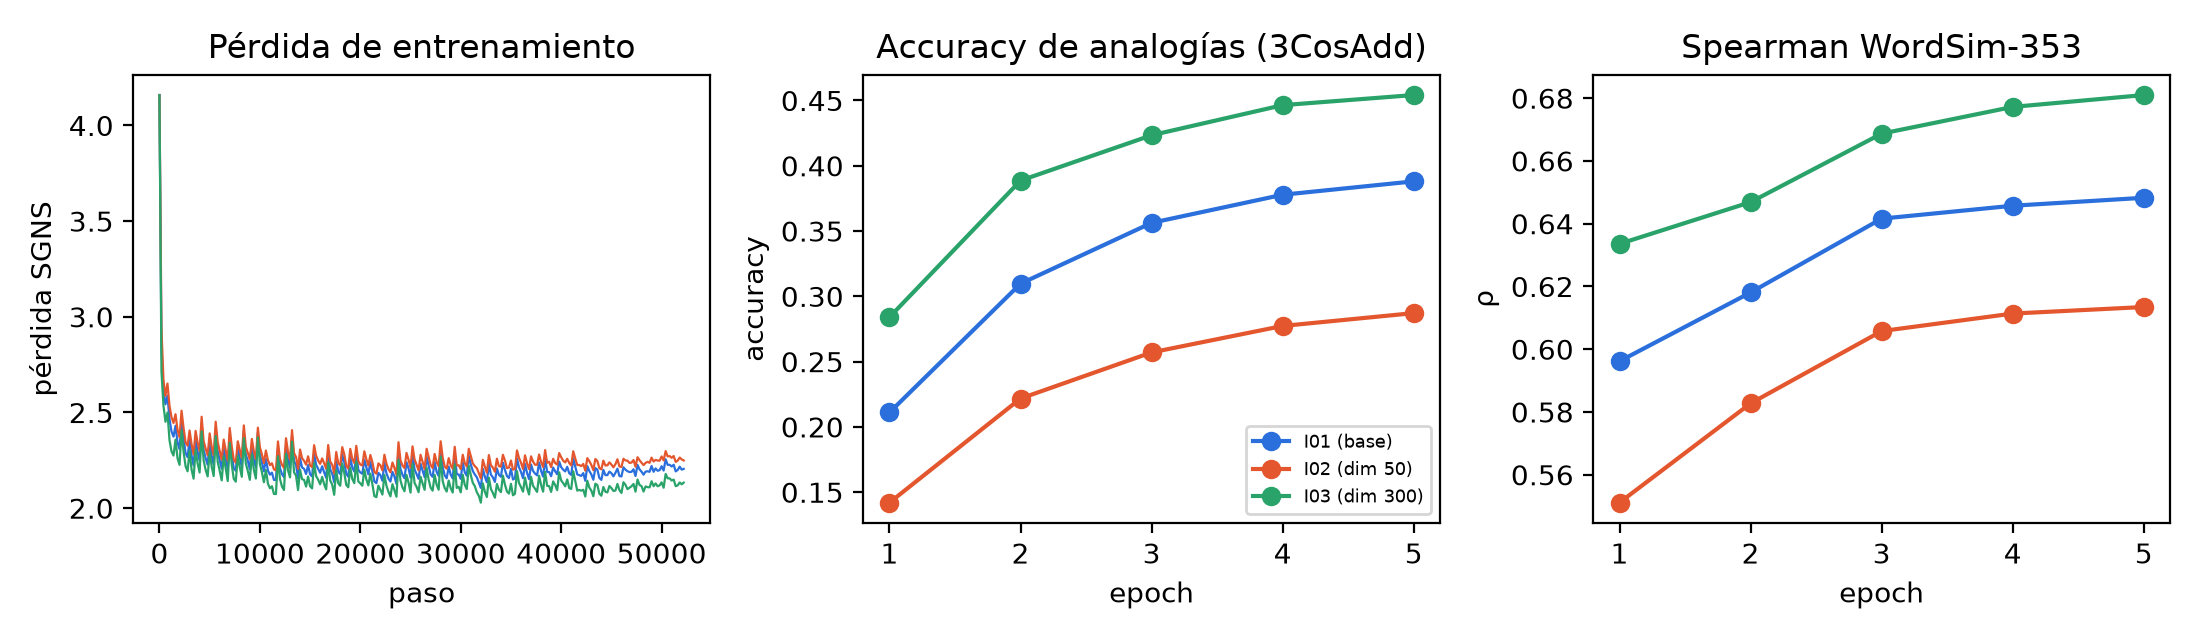

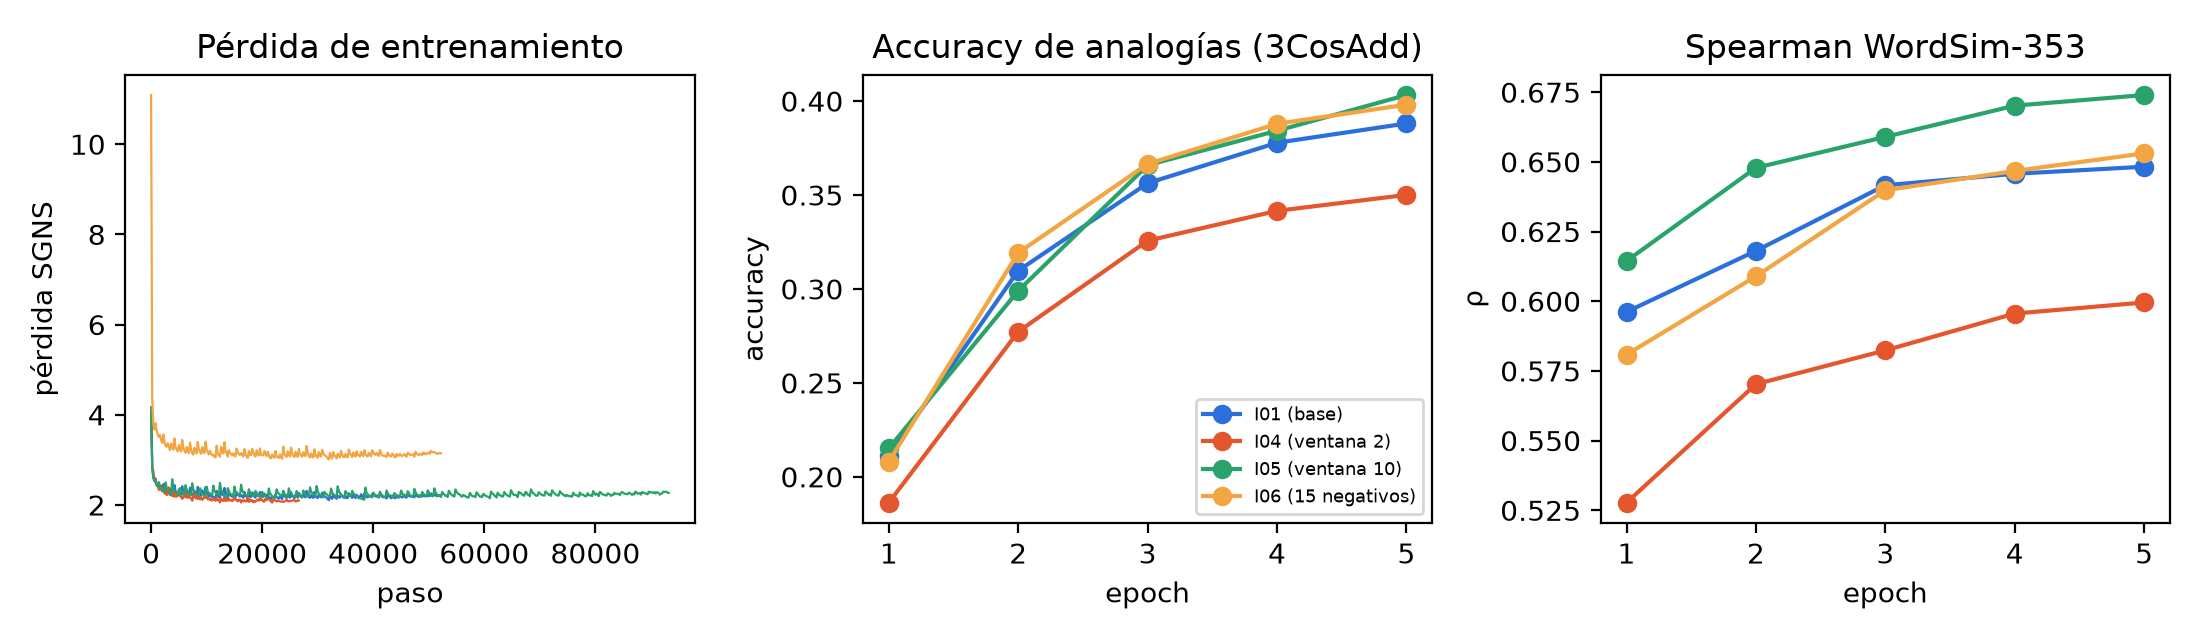

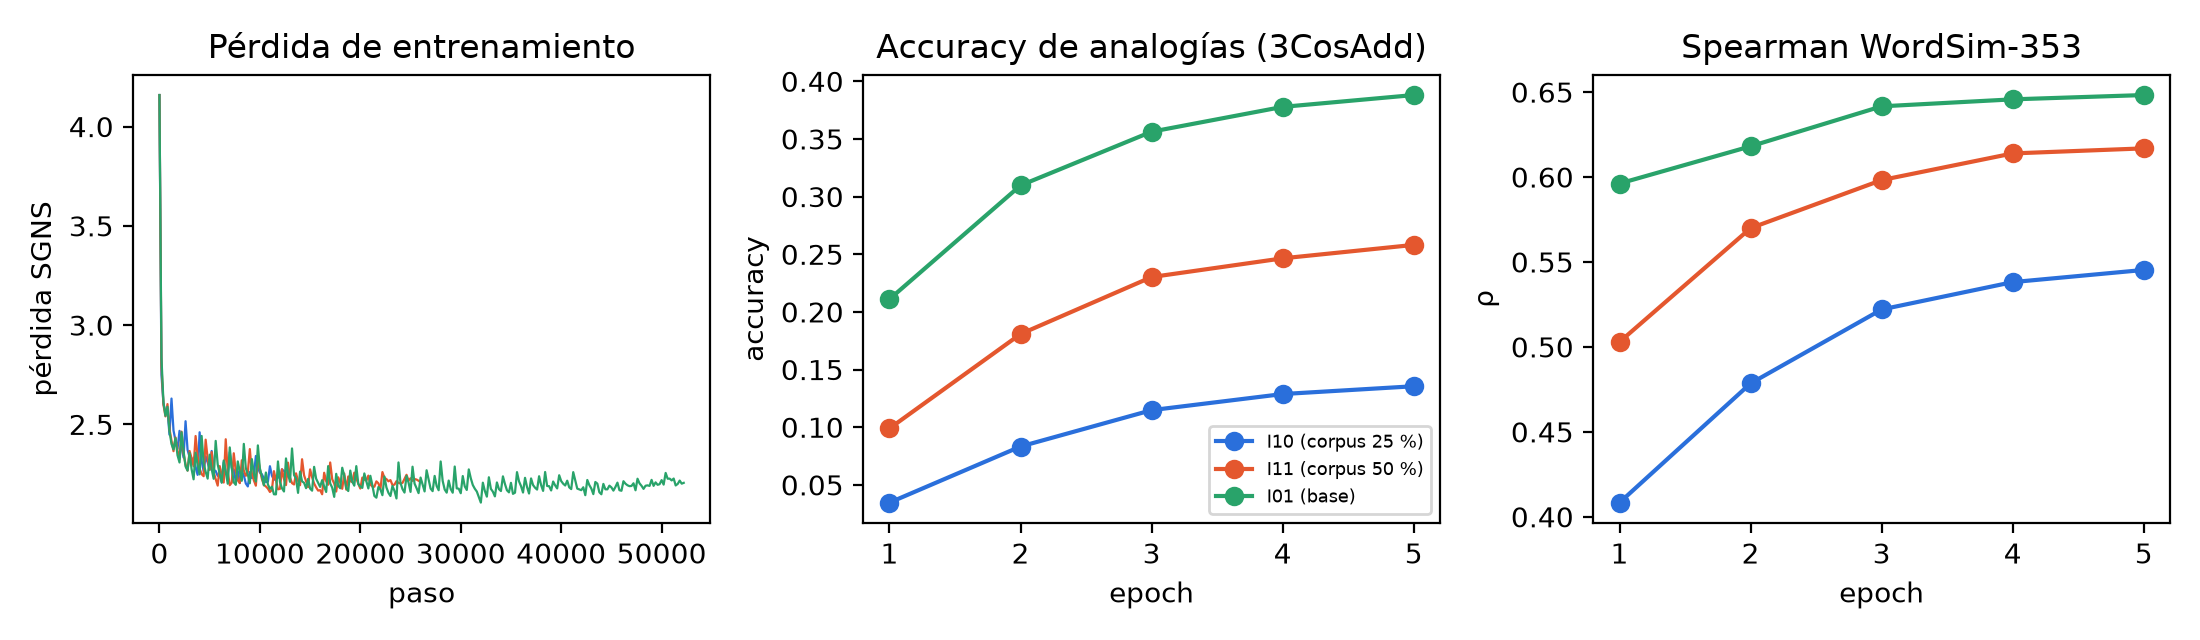

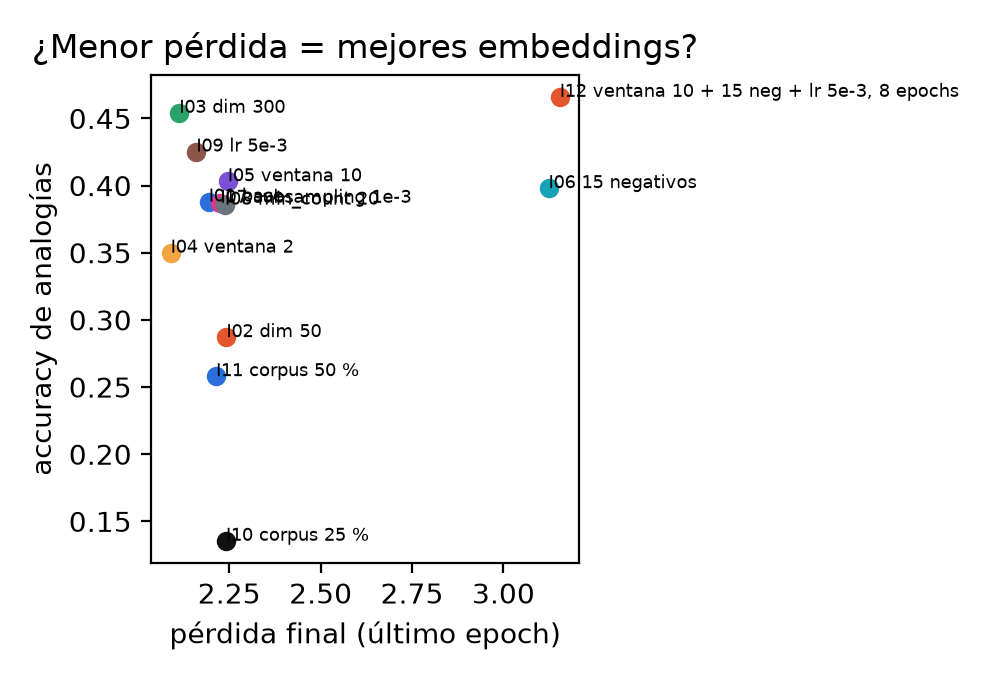

In [14]:
for name in ("02_curves_dim.png", "03_curves_window_negatives.png", "04_curves_corpus.png", "05_loss_vs_quality.png"):
    display(Image(FIG / name, width=900 if "curves" in name else 480))

Vecinos más cercanos por epoch del mejor modelo:

In [15]:
best = json.loads((R / "best_sgns.json").read_text())["name"]
for h in iters[best]["history"]:
    print(f"epoch {h['epoch']}:", {w: [n for n, _ in ns] for w, ns in h["neighbors"].items()})

epoch 1: {'king': ['1413', 'bigod', 'wardship', '1329', '1372'], 'france': ['spain', 'luxembourg', 'aquitaine', 'valenciennes', 'belgium'], 'computer': ['logg', 'openfirmware', 'raster', 'microprocessor', 'delman'], 'good': ['humoured', 'chuckle', 'cashin', 'awesomely', 'amelle'], 'january': ['february', 'november', 'december', 'october', 'june'], 'run': ['unearned', 'puhl', 'homered', 'inning', 'bacsik']}
epoch 2: {'king': ['uncrowned', 'wardship', 'vladislaus', '1328', 'lodomer'], 'france': ['luxembourg', 'belgium', 'portugal', 'spain', 'aquitaine'], 'computer': ['desktop', 'jmp', 'renderer', 'bios', 'software'], 'good': ['very', 'saskin', 'gelled', 'really', 'paltry'], 'january': ['february', 'december', 'november', 'march', 'october'], 'run': ['mccovey', 'runs', 'bacsik', 'homered', 'puhl']}
epoch 3: {'king': ['coregent', 'meresankh', 'sennacherib', 'throne', 'jagiellon'], 'france': ['french', 'belgium', 'spain', 'luxembourg', 'portugal'], 'computer': ['graphical', 'jmp', 'computer

### 4.2 Word2Vec de gensim (mismo corpus y vocabulario) y GloVe

In [16]:
gensim_runs = load("gensim_runs.json")
pd.DataFrame({k: {"tokens": v["corpus_tokens"], "vocab": v["vocab_size"], "analogías": pct(v["final"]["analogy_total"]),
                  "WordSim ρ": round(v["final"]["wordsim_spearman"], 3), "tiempo (s)": round(v["train_time_s"], 1)}
              for k, v in gensim_runs.items()}).T

,tokens,vocab,analogías,WordSim ρ,tiempo (s)
GB25,6256871,43162,17.4 %,0.562,33.6
GB50,12500765,62918,28.2 %,0.617,61.9
GB100,25000786,90566,41.1 %,0.667,128.9
GFULL,85870879,170595,51.7 %,0.661,421.3
G100,25000786,90566,44.1 %,0.66,734.4


## 5. Aritmética vectorial
### 5.1 Analogías individuales
`analogia(a, b, c, k)`: 3CosAdd sobre vectores normalizados, excluyendo a, b y c.

In [17]:
print(inspect.getsource(evaluation.analogia))
from gensim.models import KeyedVectors
kv = KeyedVectors.load(str(R / "vectors" / "best_sgns.kv"))
words, matrix = kv.index_to_key, kv.vectors
top, _ = evaluation.analogia("man", "king", "woman", 5, words, matrix)
print("propia :", [(w, round(s, 3)) for w, s in top])
print("gensim :", [(w, round(s, 3)) for w, s in kv.most_similar(positive=["king", "woman"], negative=["man"], topn=5)])

def analogia(a, b, c, k, words, matrix, exclude=True, unit=None):
    unit = normalize_rows(matrix) if unit is None else unit
    index = {w: i for i, w in enumerate(words)}
    query = unit[index[b]] - unit[index[a]] + unit[index[c]]
    query = query / np.linalg.norm(query)
    sims = unit @ query
    if exclude:
        for w in (a, b, c):
            sims[index[w]] = -np.inf
    top = np.argsort(-sims)[:k]
    return [(words[i], float(sims[i])) for i in top], sims

propia : [('queen', 0.715), ('consort', 0.71), ('throne', 0.659), ('childless', 0.65), ('eorcenberht', 0.647)]
gensim : [('queen', 0.715), ('consort', 0.71), ('throne', 0.659), ('childless', 0.65), ('eorcenberht', 0.647)]


In [18]:
va = load("vector_arithmetic.json")
rows = []
for model, m in va["models"].items():
    for r in m["individual"]:
        if r.get("missing"):
            continue
        rows.append({"modelo": model, "tipo": r["type"], "consulta": f"{r['query'][0]}:{r['query'][1]} :: {r['query'][2]}:?",
                     "esperada": r["expected"], "top-5": ", ".join(f"{w} ({s:.2f})" for w, s in r["top5"]),
                     "rango": r["rank"], "cos": r["cosine_expected"], "1.º sin excluir": r["first_no_exclusion"]})
individual = pd.DataFrame(rows)
display(individual.pivot_table(index="tipo", columns="modelo", values="rango", aggfunc=lambda s: (s == 1).mean()).map(pct))
individual

modelo,GloVe,SGNS,gensim
tipo,,,
comparativo/superlativo,66.7 %,66.7 %,33.3 %
género,100.0 %,100.0 %,33.3 %
país–capital,66.7 %,33.3 %,66.7 %
país–gentilicio,100.0 %,100.0 %,100.0 %
plural,100.0 %,100.0 %,100.0 %
tiempo verbal,66.7 %,66.7 %,100.0 %


,modelo,tipo,consulta,esperada,top-5,rango,cos,1.º sin excluir
0,SGNS,género,man:woman :: king:?,queen,"queen (0.71), consort (0.71), throne (0.66), childless (0.65), eorcenberht (0.65)",1,0.7147,king
1,SGNS,género,brother:sister :: father:?,mother,"mother (0.75), sisters (0.75), daughter (0.73), husband (0.70), her (0.69)",1,0.7534,sister
2,SGNS,género,actor:actress :: prince:?,princess,"princess (0.76), queen (0.74), duchess (0.70), caroline (0.68), anne (0.67)",1,0.7638,prince
3,SGNS,país–capital,france:paris :: italy:?,rome,"vienna (0.67), venice (0.67), milan (0.66), rome (0.65), istanbul (0.64)",4,0.6453,paris
4,SGNS,país–capital,japan:tokyo :: germany:?,berlin,"berlin (0.83), munich (0.75), frankfurt (0.71), cologne (0.68), sseldorf (0.67)",1,0.8271,berlin
5,SGNS,país–capital,spain:madrid :: russia:?,moscow,"spartak (0.69), russian (0.65), moscow (0.65), ukraine (0.64), ukrainian (0.63)",3,0.6485,russia
6,SGNS,país–gentilicio,france:french :: germany:?,german,"german (0.87), austrian (0.74), germans (0.70), russian (0.67), finnish (0.67)",1,0.8678,german
7,SGNS,país–gentilicio,china:chinese :: japan:?,japanese,"japanese (0.83), taiwanese (0.64), nihon (0.64), tokyo (0.64), minoru (0.63)",1,0.8341,japanese
8,SGNS,país–gentilicio,italy:italian :: mexico:?,mexican,"mexican (0.74), tamaulipas (0.67), veracruz (0.66), tampico (0.66), campeche (0.65)",1,0.7369,mexico
9,SGNS,comparativo/superlativo,good:better :: bad:?,worse,"worse (0.67), bigger (0.64), n't (0.59), updated (0.57), stupid (0.57)",1,0.6679,better


Sin excluir las palabras de la consulta, ¿quién sale primero?

In [19]:
pd.DataFrame({m: {"1.º es una palabra de la consulta": pct(np.mean([r["first_is_query"] for r in v["individual"] if not r.get("missing")])),
                  "coincide con most_similar de gensim": v["matches_gensim_all"]} for m, v in va["models"].items()})

,SGNS,gensim,GloVe
1.º es una palabra de la consulta,77.8 %,83.3 %,38.9 %
coincide con most_similar de gensim,True,True,True


### 5.2 Evaluación sistemática (vocabulario compartido de 30 000)

In [20]:
print("vocabulario compartido:", va["shared_vocab_size"])
cats = {}
for model, m in va["models"].items():
    for method in ("add", "mul"):
        a = m[f"analogy_{method}"]
        for cat, v in a["per_category"].items():
            cats.setdefault(cat, {})[f"{model} {method}"] = v["accuracy"]
        for agg in ("semantic", "syntactic", "total"):
            cats.setdefault(f"[{agg}]", {})[f"{model} {method}"] = a[agg]["accuracy"]
    print(model, "cobertura:", pct(m["analogy_add"]["total"]["coverage"]))
pd.DataFrame(cats).T.map(pct)

vocabulario compartido: 30000
SGNS cobertura: 60.8 %
gensim cobertura: 60.8 %
GloVe cobertura: 60.8 %


,SGNS add,SGNS mul,gensim add,gensim mul,GloVe add,GloVe mul
capital-common-countries,68.6 %,65.5 %,67.9 %,63.8 %,93.6 %,91.4 %
capital-world,58.8 %,54.2 %,57.7 %,52.1 %,88.7 %,86.3 %
currency,0.0 %,0.0 %,0.0 %,1.1 %,4.5 %,4.5 %
city-in-state,36.1 %,32.8 %,33.2 %,29.9 %,30.8 %,27.7 %
family,47.7 %,47.1 %,45.0 %,44.4 %,88.3 %,87.4 %
gram1-adjective-to-adverb,14.0 %,11.9 %,11.2 %,8.5 %,28.0 %,27.8 %
gram2-opposite,9.6 %,8.8 %,11.0 %,7.7 %,27.2 %,23.9 %
gram3-comparative,45.0 %,42.0 %,42.0 %,38.9 %,80.3 %,78.1 %
gram4-superlative,24.6 %,23.5 %,20.7 %,21.9 %,61.4 %,62.1 %
gram5-present-participle,39.2 %,32.4 %,36.0 %,29.7 %,72.2 %,71.7 %


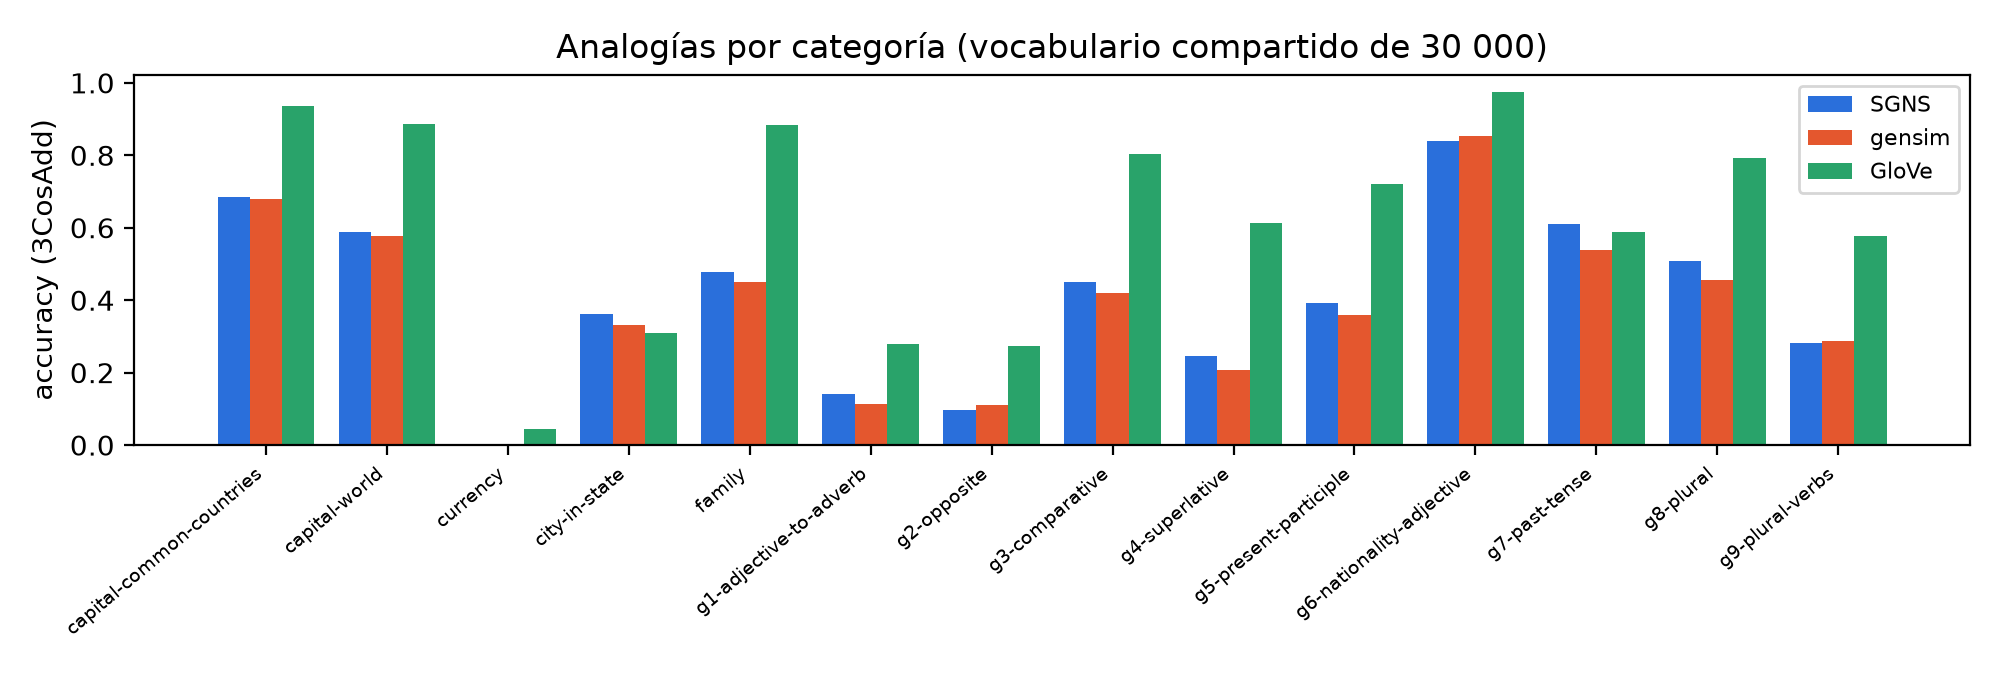

,SGNS,gensim,GloVe
capital-common-countries,0.303,0.301,0.581
capital-world,0.227,0.223,0.567
currency,0.209,0.199,0.268
city-in-state,0.165,0.190,0.341
family,0.228,0.213,0.507
gram1-adjective-to-adverb,0.087,0.081,0.271
gram2-opposite,0.110,0.092,0.231
gram3-comparative,0.255,0.248,0.424
gram4-superlative,0.238,0.229,0.465
gram5-present-participle,0.098,0.109,0.319


In [21]:
display(Image(FIG / "08_analogy_categories.png", width=900))
pd.DataFrame({m: {c: (v["mean_cosine"] if v else None) for c, v in va["models"][m]["parallelism"].items()} | {"PROMEDIO": va["models"][m]["parallelism_mean"]}
              for m in va["models"]}).round(3)

silhouette (espacio original, coseno): 0.19 | 2D: 0.492


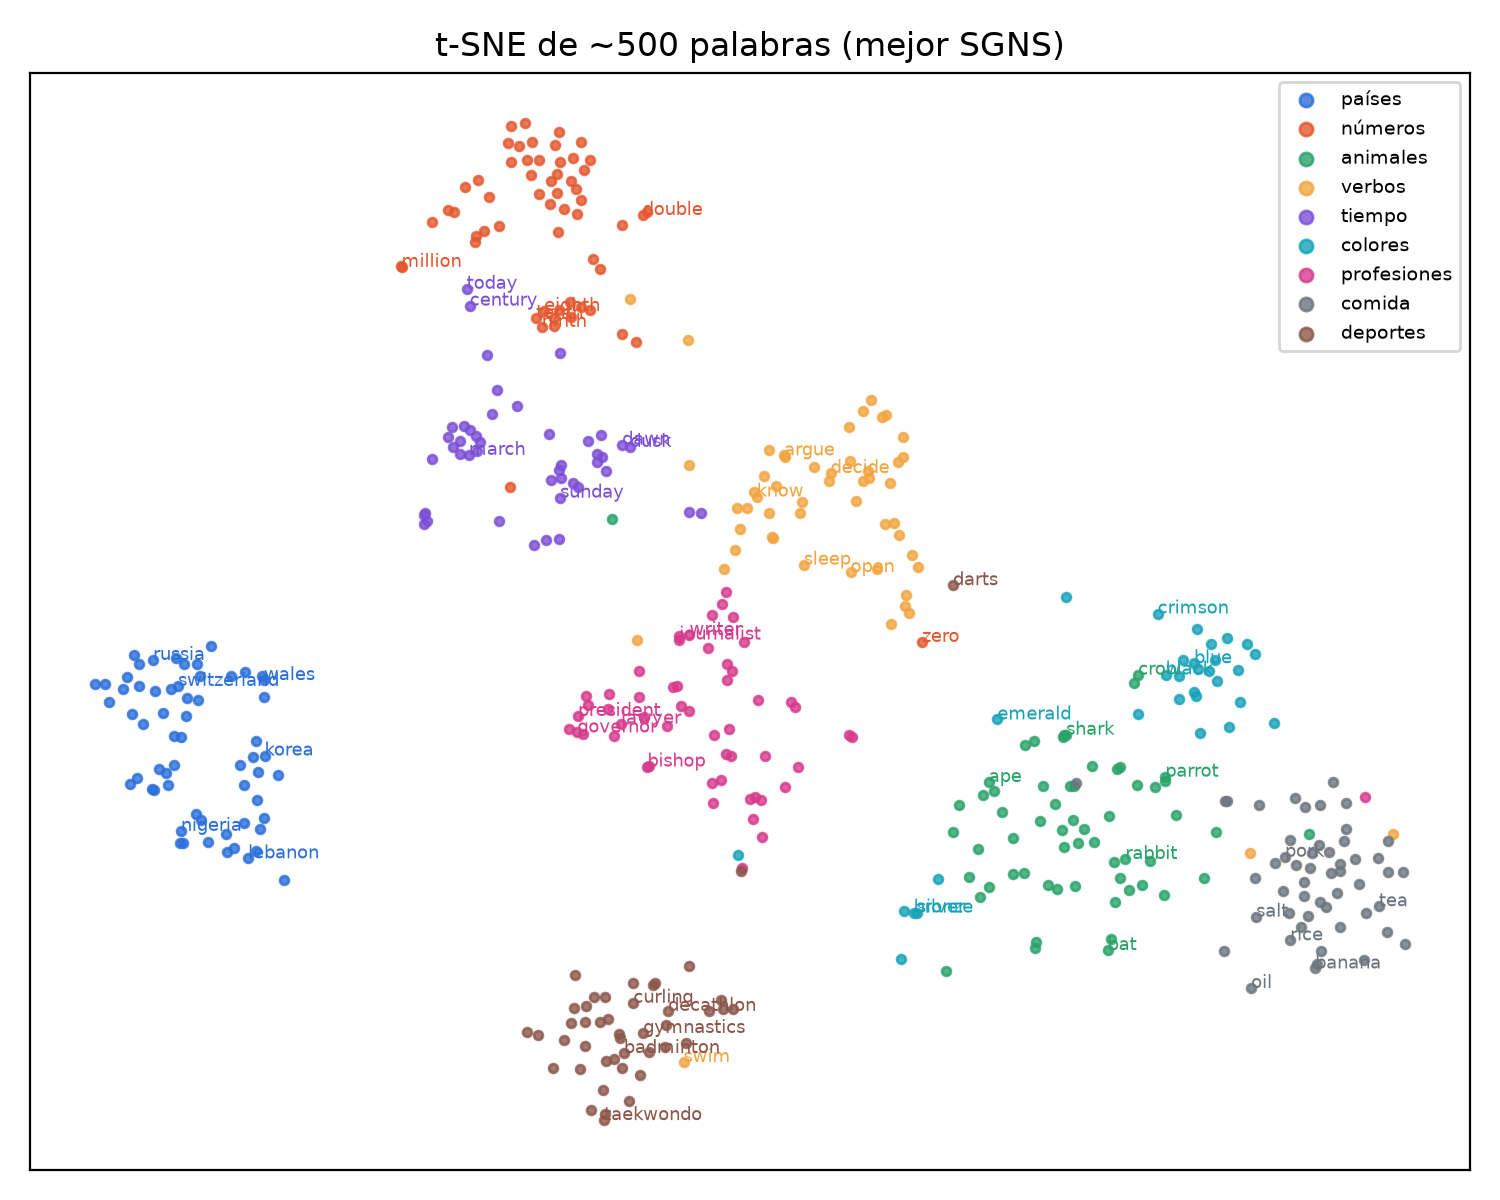

In [22]:
print("silhouette (espacio original, coseno):", round(va["tsne"]["silhouette_original"], 3), "| 2D:", round(va["tsne"]["silhouette_2d"], 3))
display(Image(FIG / "09_tsne_sgns.png", width=650))

## 6. Clasificación de AG News

In [23]:
cl = load("classification.json")
print("splits:", cl["split_sizes"], "| vocabulario del clasificador:", cl["classifier_vocab"])
print("tokens de AG News fuera del vocabulario:", {k: pct(v) for k, v in cl["oov_token_rate"].items()})
pd.DataFrame({k: {**{m: round(x, 4) for m, x in v["val"].items()}, "params": v["params_total"], "entrenables": v["params_trainable"],
                  "tiempo (s)": round(v["train_time_s"], 1)} for k, v in cl["runs"].items()}).T

splits: {'train': 108000, 'val': 12000, 'test': 7600} | vocabulario del clasificador: 43299
tokens de AG News fuera del vocabulario: {'SGNS': '3.0 %', 'gensim': '3.0 %', 'GloVe': '0.7 %'}


,accuracy,precision,recall,f1,params,entrenables,tiempo (s)
TF-IDF + LR,0.9264,0.9262,0.9264,0.9262,1690276.0,1690276.0,41.2
aleatorio,0.9135,0.9135,0.9135,0.9134,4343344.0,4343344.0,8.6
SGNS congelado,0.8826,0.8830,0.8826,0.8826,4343344.0,13444.0,3.7
SGNS fine-tuning,0.9244,0.9244,0.9244,0.9243,4343344.0,4343344.0,4.7
gensim congelado,0.8792,0.8798,0.8793,0.8792,4343344.0,13444.0,2.6
gensim fine-tuning,0.9244,0.9244,0.9244,0.9243,4343344.0,4343344.0,4.9
GloVe congelado,0.9029,0.9030,0.9029,0.9029,4343344.0,13444.0,3.7
GloVe fine-tuning,0.9247,0.9248,0.9247,0.9246,4343344.0,4343344.0,6.8


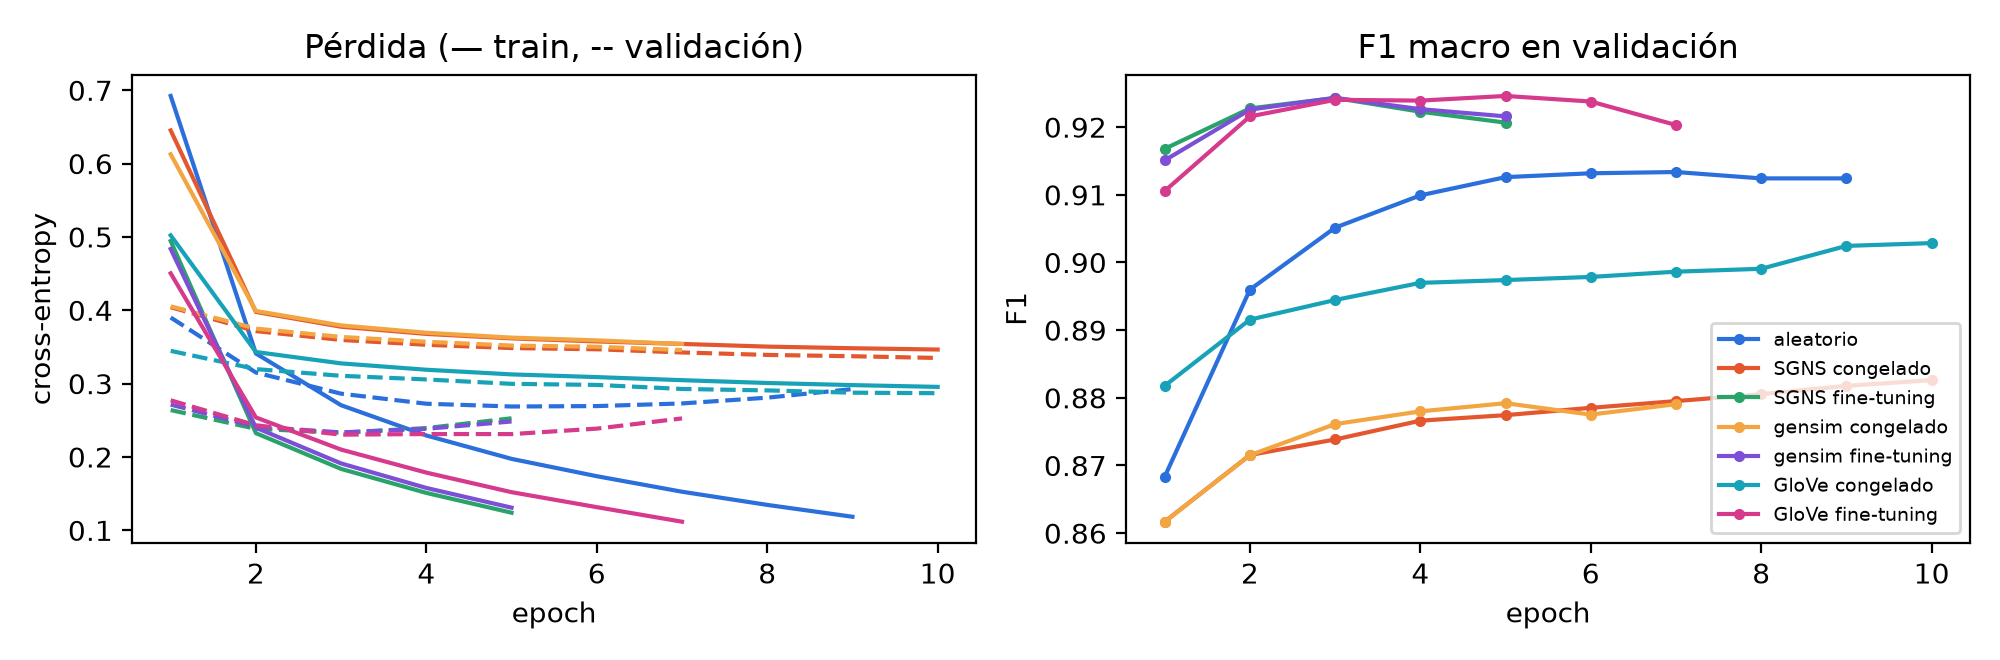

mejor variante por inicialización: {'TF-IDF': 'TF-IDF + LR', 'random': 'aleatorio', 'SGNS': 'SGNS fine-tuning', 'gensim': 'gensim fine-tuning', 'GloVe': 'GloVe fine-tuning'}


,accuracy,precision,recall,f1
TF-IDF + LR,0.9214,0.9213,0.9214,0.9213
aleatorio,0.9070,0.9071,0.9070,0.9069
SGNS fine-tuning,0.9174,0.9172,0.9174,0.9172
gensim fine-tuning,0.9163,0.9161,0.9163,0.9162
GloVe fine-tuning,0.9174,0.9174,0.9174,0.9173


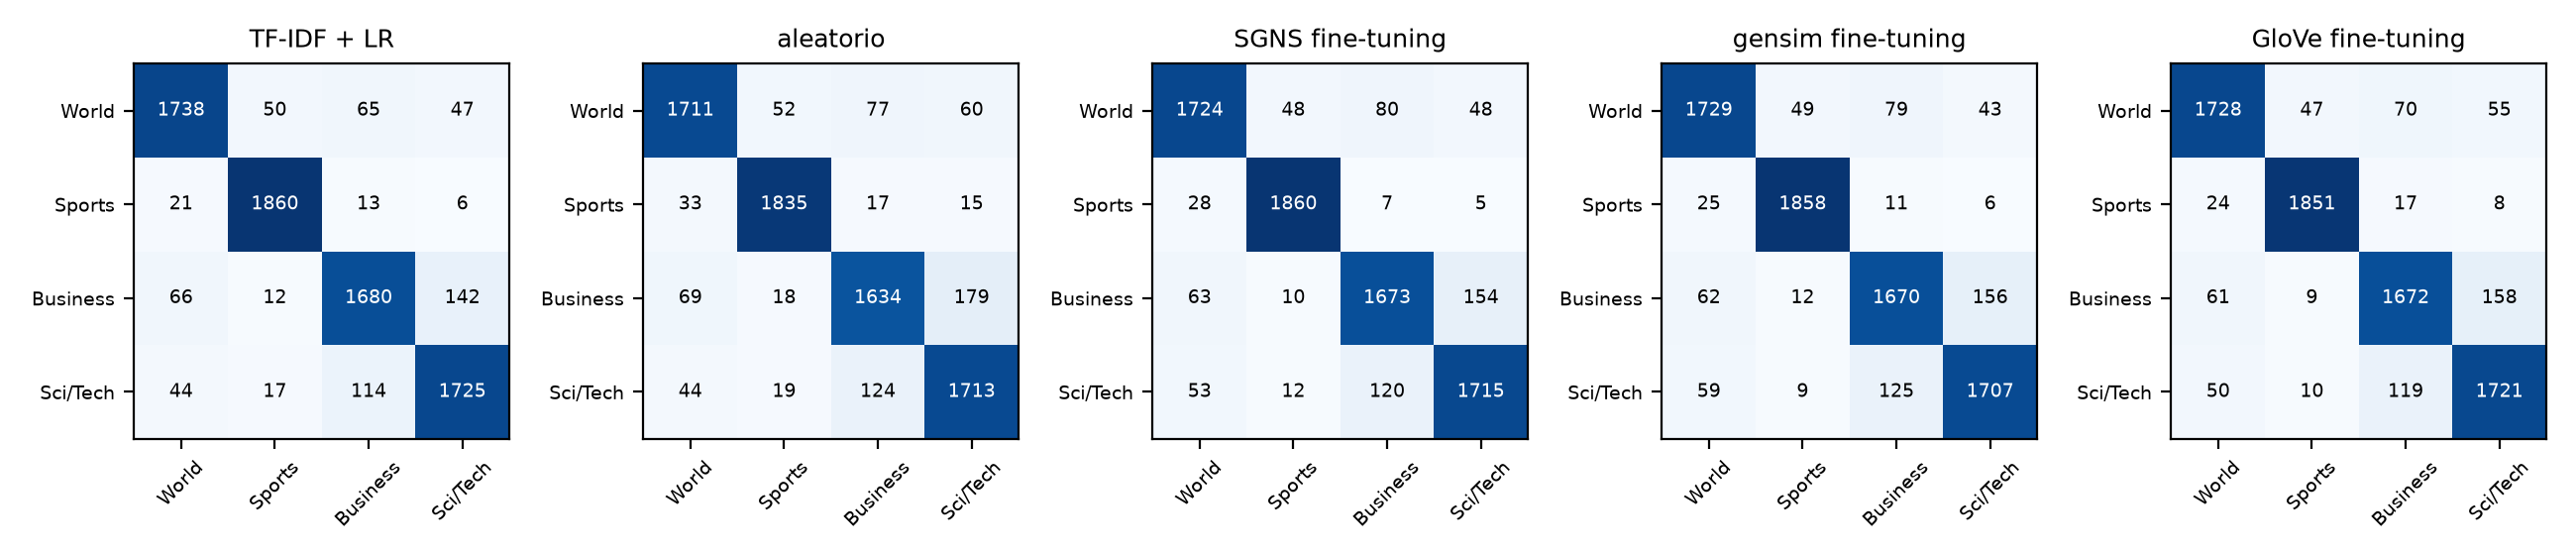

SimLex-999: {'SGNS': 0.279, 'gensim': 0.289, 'GloVe': 0.298}


In [24]:
display(Image(FIG / "10_classification_curves.png", width=900))
print("mejor variante por inicialización:", cl["best_per_init"])
display(pd.DataFrame(cl["test"]).T.round(4))
display(Image(FIG / "11_confusion.png", width=900))
print("SimLex-999:", {m: round(v["simlex"]["spearman"], 3) for m, v in va["models"].items()})

## 7. Comparación SGNS vs gensim vs GloVe

In [25]:
comp = load("comparison.json")
pd.DataFrame(comp["table"])

,SGNS,gensim,GloVe
corpus_tokens,24706643,25000786,6000000000
vocab_size,90566,90566,400000
dim,100,100,100
train_time_s,1234.361347,734.427071,NaN
hardware,NVIDIA GeForce RTX 4050 Laptop GPU,"CPU, 16 hilos","Intel Xeon E5-2658 dual a 2.1 GHz, 32 núcleos (Pennington et al., 2014)"
peak_gpu_mb,1959.15918,NaN,NaN
add_semantic,0.472262,0.452916,0.612233
add_syntactic,0.464128,0.435239,0.683061
add_total,0.466532,0.440464,0.662126
mul_semantic,0.438976,0.415363,0.587198


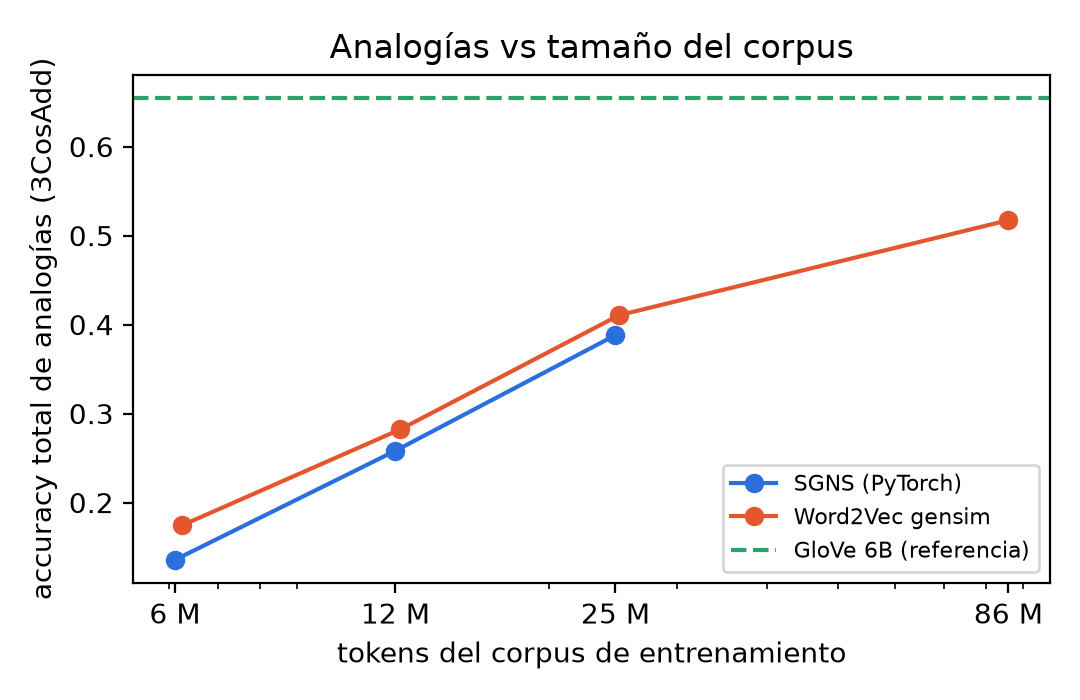

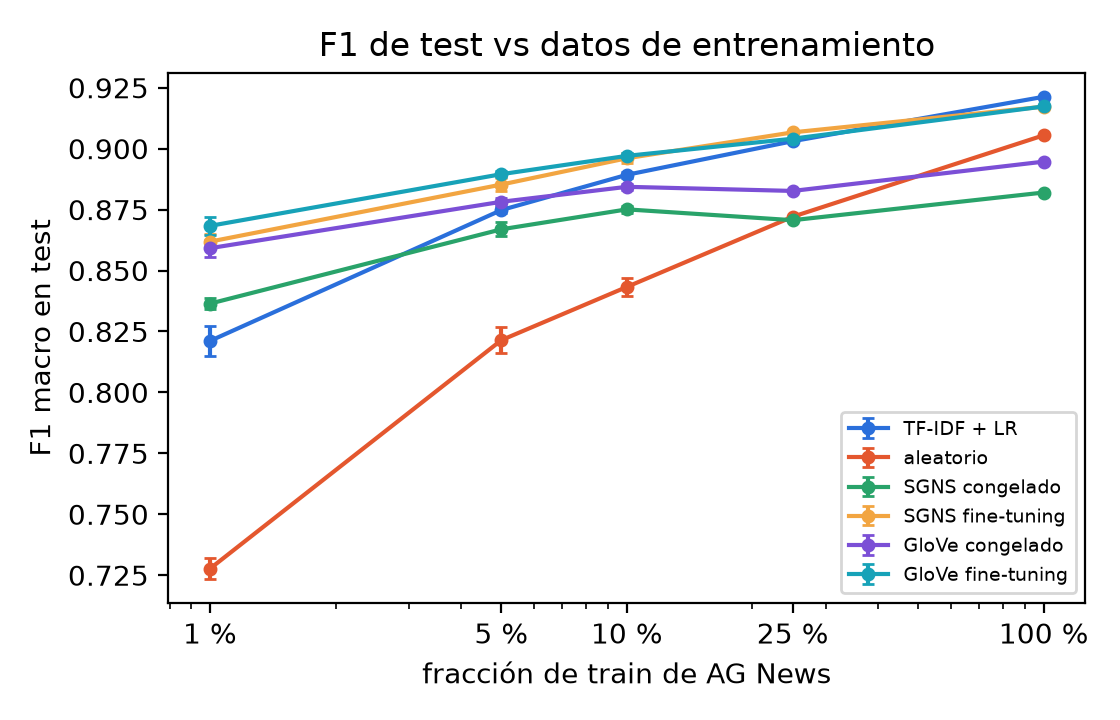

In [26]:
display(Image(FIG / "12_analogies_vs_corpus.png", width=520))
display(Image(FIG / "13_f1_vs_fraction.png", width=540))

## 8. Discusión y análisis

**1. ¿Se cumple la aritmética vectorial?** Parcialmente. El mejor SGNS resuelve el 46,7 % de las analogías (3CosAdd; 47,2 % semánticas y 46,4 % sintácticas) y 14 de 18 analogías propias. Funciona mejor en gentilicios (84 %), capitales comunes (69 %) y pasado verbal (61 %), y falla en monedas (0 %), opuestos (10 %) y adjetivo→adverbio (14 %): relaciones raras en el corpus o que no se expresan como un desplazamiento constante. En SGNS lo semántico y lo sintáctico quedan parejos; GloVe es mejor en lo sintáctico (68 % frente a 61 %).

**2. ¿El «≈» es una igualdad?** No. Sin excluir a, b y c, la palabra más cercana a b − a + c es una de la consulta en 14 de 18 casos (SGNS), 15 de 18 (gensim) y 7 de 18 (GloVe), normalmente c: el vector resultado sigue «pegado» a c. El coseno con la respuesta correcta queda entre 0,55 y 0,87, nunca 1. Y los vectores diferencia de una misma relación casi no son paralelos: su coseno medio es 0,20 (SGNS), 0,20 (gensim) y 0,41 (GloVe). La analogía acierta porque la respuesta es la *más cercana*, no porque la suma sea exacta.

**3. ¿Qué tan lejos de GloVe?** 19,5 puntos (46,7 % frente a 66,2 %). Lo explica sobre todo el corpus: con la misma configuración, gensim pasa de 17,4 % (6 M tokens) a 28,2 % (12 M), 41,1 % (25 M) y 51,7 % (86 M): entre 11 y 13 puntos por cada duplicación hasta 25 M, y luego +10,6 al multiplicar por 3,4, con rendimiento decreciente pero sin estancarse. GloVe vio 6 000 M de tokens (240 veces más). Los hiperparámetros aportan menos: ajustarlos con el mismo corpus subió de 38,8 % a 46,6 % (+7,8 puntos).

**4. ¿SGNS propio vs gensim?** Muy parecidos: 38,8 % frente a 41,1 % con la configuración base y 46,7 % frente a 44,0 % con la mejor; WordSim 0,665 frente a 0,660; SimLex 0,279 frente a 0,290; las mismas categorías fuertes y débiles. Las diferencias vienen del optimizador (SparseAdam con lotes de 8 192 pares frente a SGD por par con lr lineal de 0,025), de la tabla de negativos y del muestreo aleatorio.

**5. Dimensión, ventana y negativos.** Dimensión 50 → 100 → 300: 28,7 % → 38,8 % → 45,4 %, a cambio de 5 veces más tiempo. Ventana 2 → 5 → 10: las semánticas suben de 22,0 % a 27,6 % y a 32,5 %, mientras las sintácticas casi no cambian (40,5 %, 43,5 %, 43,6 %). La ventana pequeña favorece lo sintáctico en términos relativos (la información sintáctica está en los vecinos inmediatos) y la grande aporta el tema (semántica). 15 negativos: +1 punto. lr 5e-3: +3,7 puntos. **Una pérdida más baja no implica mejores embeddings**: la ventana 2 tiene la pérdida más baja (2,09) y peores analogías (35,0 %); I12 tiene una de las más altas (3,15) y es el mejor. La pérdida depende de la tarea que se define (número de negativos, ventana), no de la calidad.

**6. AG News.** Con el 100 % de los datos, en test: TF-IDF 92,1 % > GloVe FT 91,7 % ≈ SGNS FT 91,7 % > aleatorio 90,7 % (F1 macro). Los preentrenados superan a los aleatorios (+1 punto), pero no a TF-IDF con bigramas, porque con 108 000 noticias las palabras clave bastan. Congelar siempre rindió menos que el fine-tuning (88,3 % frente a 92,4 % en validación con SGNS), aunque entrena 320 veces menos parámetros (13 444 frente a 4,3 M). **Con el 1 %** (1 080 noticias) todo cambia: GloVe FT 86,8 %, SGNS FT 86,2 %, GloVe congelado 85,9 %, SGNS congelado 83,6 %, TF-IDF 82,1 % y aleatorio 72,8 %. Los embeddings preentrenados aportan el conocimiento que esos pocos datos no tienen (+14 puntos frente a aleatorio), y congelar queda a menos de 1 punto del fine-tuning en GloVe: con pocos datos, congelar es una opción razonable.

**Conclusión.** Implementar SGNS desde cero reproduce el comportamiento de gensim. La aritmética vectorial funciona como *vecino más cercano*, no como igualdad. La calidad de los embeddings depende sobre todo del tamaño del corpus. Y su valor en una tarea real aparece cuando hay pocos datos etiquetados.